In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
#at birth outcome (if we need to cut off diagnoses or not)
at_birth = False
#Features used and diag cut off if at birth = False
cutoff = 12
#include SES and racial variables in predictions
ses = True

In [38]:
from sklearn.model_selection import train_test_split

pretrained_model = '/results/GDM_12w.json'

df = pd.read_csv('/data/pregnancy_complications_synthetic.csv')
outcome = 'GDM'
df['GDM'] = df['outcome']
train_df, test_df = train_test_split(df, test_size=0.20)

X_train = train_df
X_test = test_df

y_train = train_df[outcome]
y_test = test_df[outcome]

print(train_df.shape)
print(test_df.shape)

(4000, 311)
(1000, 311)


## Models

In [39]:
import os
import subprocess

from sklearn import utils
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import auc, precision_recall_curve, accuracy_score, confusion_matrix, roc_auc_score, average_precision_score, balanced_accuracy_score, precision_score, recall_score
from sklearn.metrics import brier_score_loss, log_loss, roc_curve, f1_score
from sklearn.model_selection import train_test_split

import joblib

In [40]:
from sklearn.calibration import calibration_curve

def metrics_at_screen_rate(y_true, y_prob, screen_rate):

    n = len(y_prob)
    cutoff_index = int(np.ceil((1 - screen_rate) * n))

    threshold = np.sort(y_prob)[cutoff_index]

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)
    
    n_screened = int(screen_rate * n)

    return {
        "screen_rate": screen_rate,
        "threshold": threshold,
        'n screened': n_screened,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "ppv": ppv,
        "npv": npv
    }

def screening_curve(y_true, probs, percentiles=np.linspace(0.01, 0.5, 50)):
    df = pd.DataFrame({
        "y": y_true,
        "p": probs
    }).sort_values("p", ascending=False).reset_index(drop=True)

    total_positives = df["y"].sum()

    results = []
    n = len(df)

    for pct in percentiles:
        k = int(pct * n)
        subset = df.iloc[:k]

        captured = subset["y"].sum()
        recall = captured / total_positives if total_positives > 0 else 0
        precision = captured / k if k > 0 else 0

        results.append({
            "percentile": pct,
            "recall": recall,
            "precision": precision,
            "captured": captured
        })

    return pd.DataFrame(results)

def sample_points_for_plot(y_true, probs, n_samples=200):
    df = pd.DataFrame({"y": y_true, "p": probs})
    df = df.sort_values("p", ascending=False).reset_index(drop=True)
    df["percentile"] = np.arange(len(df)) / len(df)
    df["percentile_flipped"] = 1 - df["percentile"]

    return df.sample(min(n_samples, len(df)), random_state=42)

In [41]:
#Calcuates performance metrics for models
#Option to save incorrect and correct ids for downstream analysis
def prob_metrics(targets, preds, probs, save, test):

    targets = targets.values
    targets = np.reshape(targets, preds.shape[0])

    probs = np.clip(probs, 0, 1)
    precision, recall, _ = precision_recall_curve(targets, probs)
    fpr, tpr, _ = roc_curve(targets, probs)
    
    res = {
        'AUROC': roc_auc_score(targets, probs),
        'AUPRC': auc(recall, precision),
        'Precision': precision,
        'Recall': recall,
        'FPRs': fpr,
        'TPRs': tpr,
    }
   
    return res

In [42]:
#Defines subgroups to calculate performance metrics on
conditions = {
        'Hispanic': (df['Hispanic'] == 1),
        'NH White': (df['NH_White'] == 1),
        'NH Black': (df['NH_Black'] == 1),
        'Asian': (df['NH_Asian'] == 1),
        'Other': (df['Other'] == 1),
        'Under 25': (df['mage'] < 25.0),
        '25 - 29': (df['mage'] >= 25.0) & (df['mage'] < 30.0),
        '30 - 34': (df['mage'] >= 30.0) & (df['mage'] < 35.0),
        '35+': (df['mage'] >= 35.0),
        'Nulliparous': (df['parity'] == 0),
        'Multiparous': (df['parity'] == 1),
        'Not Reported': (df['PPREG_BMI'] == 0.0),
        'Obesity': (df['PPREG_BMI'] >= 30),
        'Without Obesity': (df['PPREG_BMI'] > 0.0) & (df['PPREG_BMI'] < 30)
    }

In [43]:
#Given a dataframe, calculates members of each subgroup
def generate_conditions(df):
    conditions = {
        'Hispanic': (df['Hispanic'] == 1),
        'NH White': (df['NH_White'] == 1),
        'NH Black': (df['NH_Black'] == 1),
        'Asian': (df['NH_Asian'] == 1),
        'Other': (df['Other'] == 1),
        'Under 25': (df['mage'] < 25.0),
        '25 - 29': (df['mage'] >= 25.0) & (df['mage'] < 30.0),
        '30 - 34': (df['mage'] >= 30.0) & (df['mage'] < 35.0),
        '35+': (df['mage'] >= 35.0),
        'Nulliparous': (df['parity'] == 0),
        'Multiparous': (df['parity'] == 1),
        'Not Reported': (df['PPREG_BMI'] == 0.0),
        'Obesity': (df['PPREG_BMI'] >= 30),
        'Without Obesity': (df['PPREG_BMI'] > 0.0) & (df['PPREG_BMI'] < 30)
    }
    return conditions

In [44]:
nan_columns_train = X_train.columns[X_train.isna().all()]

print(nan_columns_train)

X_train = X_train.drop(columns=nan_columns_train)
X_test = X_test.drop(columns=nan_columns_train)
df =  df.drop(columns=nan_columns_train)

Index([], dtype='object')


In [45]:
print(X_train)
print(X_test)
print(y_train)
print(y_test)

      Unnamed: 0    id  pp_ALT_avg  pp_ALT_min  pp_ALT_max  pp_ALT_std  \
4245        4245  4246      21.717      17.545      25.889       2.086   
1403        1403  1404      23.373      19.512      27.234       1.930   
4143        4143  4144      25.905      21.364      30.446       2.271   
2845        2845  2846      33.074      30.329      35.819       1.372   
1976        1976  1977      28.737      23.544      33.930       2.597   
...          ...   ...         ...         ...         ...         ...   
2235        2235  2236      43.169      38.151      48.188       2.509   
3255        3255  3256      40.640      38.238      43.042       1.201   
2891        2891  2892      46.845      41.246      52.443       2.799   
1666        1666  1667      42.193      37.065      47.321       2.564   
2373        2373  2374      21.280      16.077      26.482       2.601   

      pp_AST_avg  pp_AST_min  pp_AST_max  pp_AST_std  ...  PPREG_BMI  parity  \
4245      28.079      26.457   

In [46]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(4000, 311)
(4000,)
(1000, 311)
(1000,)


In [47]:
print(list(df.columns))

['Unnamed: 0', 'id', 'pp_ALT_avg', 'pp_ALT_min', 'pp_ALT_max', 'pp_ALT_std', 'pp_AST_avg', 'pp_AST_min', 'pp_AST_max', 'pp_AST_std', 'pp_CREATININE_avg', 'pp_CREATININE_min', 'pp_CREATININE_max', 'pp_CREATININE_std', 'pp_GLU_F_avg', 'pp_GLU_F_min', 'pp_GLU_F_max', 'pp_GLU_F_std', 'pp_GLU_RAN_avg', 'pp_GLU_RAN_min', 'pp_GLU_RAN_max', 'pp_GLU_RAN_std', 'pp_HGB_avg', 'pp_HGB_min', 'pp_HGB_max', 'pp_HGB_std', 'pp_RBC_avg', 'pp_RBC_min', 'pp_RBC_max', 'pp_RBC_std', 'pp_WBC_avg', 'pp_WBC_min', 'pp_WBC_max', 'pp_WBC_std', 'pp_ANC_avg', 'pp_ANC_min', 'pp_ANC_max', 'pp_ANC_std', 'pp_CHLORIDE_avg', 'pp_CHLORIDE_min', 'pp_CHLORIDE_max', 'pp_CHLORIDE_std', 'pp_CALCIUM_avg', 'pp_CALCIUM_min', 'pp_CALCIUM_max', 'pp_CALCIUM_std', 'pp_BUN_avg', 'pp_BUN_min', 'pp_BUN_max', 'pp_BUN_std', 'pp_GTT75_2_avg', 'pp_GTT75_2_min', 'pp_GTT75_2_max', 'pp_GTT75_2_std', 'pp_GTT_1_avg', 'pp_GTT_1_min', 'pp_GTT_1_max', 'pp_GTT_1_std', 'pp_GTT_2_avg', 'pp_GTT_2_min', 'pp_GTT_2_max', 'pp_GTT_2_std', 'pp_GTT_3_avg', 'pp

In [48]:
#Labs and vitals
#changed to match synthetic indexing
feats_to_train = list(df.columns)[2:266]


In [49]:
print(feats_to_train)

['pp_ALT_avg', 'pp_ALT_min', 'pp_ALT_max', 'pp_ALT_std', 'pp_AST_avg', 'pp_AST_min', 'pp_AST_max', 'pp_AST_std', 'pp_CREATININE_avg', 'pp_CREATININE_min', 'pp_CREATININE_max', 'pp_CREATININE_std', 'pp_GLU_F_avg', 'pp_GLU_F_min', 'pp_GLU_F_max', 'pp_GLU_F_std', 'pp_GLU_RAN_avg', 'pp_GLU_RAN_min', 'pp_GLU_RAN_max', 'pp_GLU_RAN_std', 'pp_HGB_avg', 'pp_HGB_min', 'pp_HGB_max', 'pp_HGB_std', 'pp_RBC_avg', 'pp_RBC_min', 'pp_RBC_max', 'pp_RBC_std', 'pp_WBC_avg', 'pp_WBC_min', 'pp_WBC_max', 'pp_WBC_std', 'pp_ANC_avg', 'pp_ANC_min', 'pp_ANC_max', 'pp_ANC_std', 'pp_CHLORIDE_avg', 'pp_CHLORIDE_min', 'pp_CHLORIDE_max', 'pp_CHLORIDE_std', 'pp_CALCIUM_avg', 'pp_CALCIUM_min', 'pp_CALCIUM_max', 'pp_CALCIUM_std', 'pp_BUN_avg', 'pp_BUN_min', 'pp_BUN_max', 'pp_BUN_std', 'pp_GTT75_2_avg', 'pp_GTT75_2_min', 'pp_GTT75_2_max', 'pp_GTT75_2_std', 'pp_GTT_1_avg', 'pp_GTT_1_min', 'pp_GTT_1_max', 'pp_GTT_1_std', 'pp_GTT_2_avg', 'pp_GTT_2_min', 'pp_GTT_2_max', 'pp_GTT_2_std', 'pp_GTT_3_avg', 'pp_GTT_3_min', 'pp_GTT

In [50]:
#Append history features 
orig_cos = ['familyhx_dm_ever', 'dep_priorlmp', 'smk_prior', 'alc_prior', 'pcos', 'hxpe_e', 'hxghtn', 'hxgdm', 'hxabrt', 'mage', 'PPREG_BMI', 'parity', 'cancer_prepreg', 'ga_office1st', 'ins_medi']
new_cos = ['chest_pain', 'uti', 'hyperkeratosis', 'carp_tunnel', 'hypercholes', 'cyst_ovary', 'wart', 'pain_rightquad', 'viraldisease_preg', 'resp_infection', 'pain_neck', 'pain_joint', 'pain_chronic', 'acne', 'breast_lump', 'pain_limb', 'ab_pain', 'ten_headache', 'headache', 'viraldisease']
for i in range(len(orig_cos)):
    feats_to_train.append(orig_cos[i])

for i in range(len(new_cos)):
    feats_to_train.append(new_cos[i])

if outcome != 'GDM':
    feats_to_train.append('dm')

if outcome != 'ghtn':
    feats_to_train.append('chtn_prepreg')
    
if cutoff > 12:
    feats_to_train.append('preg_single')
    
if (cutoff > 18) and (outcome != 'ghtn'):
    feats_to_train.append('chtn_earlypreg')

'''
if outcome == 'GDM':
    bad_cols =  X_train.columns[X_train.columns.str.contains('GTT')].tolist()
    print(bad_cols)
    feats_to_train = [x for x in feats_to_train if x not in bad_cols]
    print(feats_to_train)
    X_train = X_train.loc[:,  ~X_train.columns.str.contains('GTT')]
    X_test = X_test.loc[:, ~X_test.columns.str.contains('GTT')]
'''
if ses == True:
    feats_to_train.append('Hispanic')
    feats_to_train.append('NH_White')
    feats_to_train.append('NH_Black')
    feats_to_train.append('NH_Asian')
    feats_to_train.append('Other')

In [51]:
print(feats_to_train)

['pp_ALT_avg', 'pp_ALT_min', 'pp_ALT_max', 'pp_ALT_std', 'pp_AST_avg', 'pp_AST_min', 'pp_AST_max', 'pp_AST_std', 'pp_CREATININE_avg', 'pp_CREATININE_min', 'pp_CREATININE_max', 'pp_CREATININE_std', 'pp_GLU_F_avg', 'pp_GLU_F_min', 'pp_GLU_F_max', 'pp_GLU_F_std', 'pp_GLU_RAN_avg', 'pp_GLU_RAN_min', 'pp_GLU_RAN_max', 'pp_GLU_RAN_std', 'pp_HGB_avg', 'pp_HGB_min', 'pp_HGB_max', 'pp_HGB_std', 'pp_RBC_avg', 'pp_RBC_min', 'pp_RBC_max', 'pp_RBC_std', 'pp_WBC_avg', 'pp_WBC_min', 'pp_WBC_max', 'pp_WBC_std', 'pp_ANC_avg', 'pp_ANC_min', 'pp_ANC_max', 'pp_ANC_std', 'pp_CHLORIDE_avg', 'pp_CHLORIDE_min', 'pp_CHLORIDE_max', 'pp_CHLORIDE_std', 'pp_CALCIUM_avg', 'pp_CALCIUM_min', 'pp_CALCIUM_max', 'pp_CALCIUM_std', 'pp_BUN_avg', 'pp_BUN_min', 'pp_BUN_max', 'pp_BUN_std', 'pp_GTT75_2_avg', 'pp_GTT75_2_min', 'pp_GTT75_2_max', 'pp_GTT75_2_std', 'pp_GTT_1_avg', 'pp_GTT_1_min', 'pp_GTT_1_max', 'pp_GTT_1_std', 'pp_GTT_2_avg', 'pp_GTT_2_min', 'pp_GTT_2_max', 'pp_GTT_2_std', 'pp_GTT_3_avg', 'pp_GTT_3_min', 'pp_GTT

In [52]:
hold_feats = X_train 
hold_test = X_test

boot_fprs, boot_tprs, boot_precisions, boot_recalls, boot_f1, aucs, prcs, f1s = [], [], [], [], [], [], [], []
total, total_pos, test_pos, test_total = [], [], [], []            
     
subgroup_perf = {group: {'AUROC': [], 'AUPRC': [], 'F1': []} for group in conditions.keys()}
subgroup_perf_ci = {group: {'AUROC': [], 'AUPRC': [], 'F1': []} for group in conditions.keys()}
subgroup_perf_stats = {group: {'Test': [], 'Total': [], 'F1': []} for group in conditions.keys()}

In [53]:
print("--------------------------------- ")
print("----- " + str(outcome) + " ----- ")
print("--------------------------------- ")
print("")
print("Total final: " + str(X_train.shape[0] + X_test.shape[0]))
print("Total positive cases: " + str(int(len(y_train[y_train == 1]) + len(y_test[y_test == 1]))))

##Scale training data
X_train = X_train[feats_to_train]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test[feats_to_train])

#Uncomment for re-training
'''
##XGBoost weighted for rare outcome
xgb = XGBClassifier(random_state = 42)

#Search for best hyperparamters
param_grid = {
    'lambda': [0.5, 1, 1.5],
    'subsample': [0.75, 1],
    'max_depth': [2, 4, 6, 8],
    'eta': [0.01, 0.05, 0.1],
    'gamma': [0, 0.25, 0.5]
}

cv_rf = GridSearchCV(estimator=xgb, param_grid=param_grid, refit = True, cv = 5, scoring = 'roc_auc').fit(X_train, y_train)
print("Best Parameters:", cv_rf.best_params_)

cv_rf.best_estimator_.save_model("static-xgb-7-2/" + model_name + ".json")

#Feature importances
feat_importances = cv_rf.best_estimator_.feature_importances_
'''

--------------------------------- 
----- GDM ----- 
--------------------------------- 

Total final: 5000
Total positive cases: 222


'\n##XGBoost weighted for rare outcome\nxgb = XGBClassifier(random_state = 42)\n\n#Search for best hyperparamters\nparam_grid = {\n    \'lambda\': [0.5, 1, 1.5],\n    \'subsample\': [0.75, 1],\n    \'max_depth\': [2, 4, 6, 8],\n    \'eta\': [0.01, 0.05, 0.1],\n    \'gamma\': [0, 0.25, 0.5]\n}\n\ncv_rf = GridSearchCV(estimator=xgb, param_grid=param_grid, refit = True, cv = 5, scoring = \'roc_auc\').fit(X_train, y_train)\nprint("Best Parameters:", cv_rf.best_params_)\n\ncv_rf.best_estimator_.save_model("static-xgb-7-2/" + model_name + ".json")\n\n#Feature importances\nfeat_importances = cv_rf.best_estimator_.feature_importances_\n'

In [54]:
###
#Load pretrained model
###
best = XGBClassifier(random_state=42)
best.load_model(pretrained_model)

test_preds = best.predict(X_test)
test_probs = best.predict_proba(X_test)[:,1]

print("Average Risk for Pos Patients: " + str(round(test_probs[y_test == 1].mean(), 5)))
print("Average Risk for Neg Patients: " + str(round(test_probs[y_test == 0].mean(), 5)))


Average Risk for Pos Patients: 0.05891
Average Risk for Neg Patients: 0.04277


# Calibration curve and screen 

{'AUROC': 0.7093363606521501, 'AUPRC': 0.09564206717665973, 'Precision': array([0.038     , 0.0392562 , 0.04139434, 0.04143948, 0.04241071,
       0.04250559, 0.04255319, 0.04347826, 0.04357798, 0.04252874,
       0.04262673, 0.04267589, 0.04272517, 0.04302326, 0.04312354,
       0.04342723, 0.04326329, 0.04331683, 0.04391468, 0.0443038 ,
       0.04435995, 0.04441624, 0.04447268, 0.04452926, 0.04458599,
       0.04464286, 0.0449294 , 0.04504505, 0.04521964, 0.04427083,
       0.04432855, 0.04473684, 0.04491413, 0.04497354, 0.04503311,
       0.04495913, 0.04508197, 0.04520548, 0.04558011, 0.04564315,
       0.04570637, 0.04583333, 0.04775687, 0.04782609, 0.04803493,
       0.04845815, 0.04852941, 0.04740741, 0.04747774, 0.04761905,
       0.04769001, 0.04783259, 0.05220228, 0.05237316, 0.05245902,
       0.05263158, 0.05298013, 0.05315615, 0.05333333, 0.05470085,
       0.05488851, 0.05507745, 0.0552677 , 0.05536332, 0.05545927,
       0.05565217, 0.05574913, 0.05594406, 0.05807623, 0

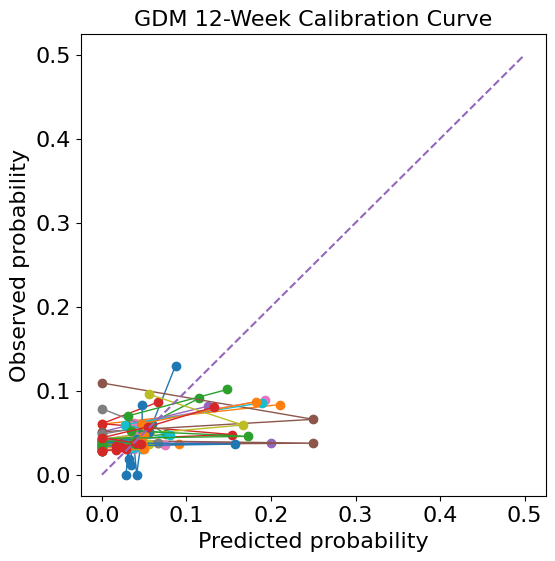

In [55]:
# Evaluate predictions
prob_metrics_1 = prob_metrics(y_test, test_preds, test_probs, False, X_test)

print(prob_metrics_1)

df_x_test_original = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=feats_to_train
)
    
rates = [0.05, 0.10, 0.20]

results = [metrics_at_screen_rate(y_test, test_probs, r) for r in rates]

results_df = pd.DataFrame(results)

prob_true_plot, prob_pred_plot = calibration_curve(
    y_test,
    test_probs,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_plot, prob_true_plot, marker="o", label="Overall", linewidth=1)

print(results_df)

df_x_test = df_x_test_original.copy().reset_index(drop=True)
df_y_test = y_test.copy().reset_index(drop=True)

conditions = generate_conditions(df_x_test)
for group, condition in conditions.items():

    subgroup_indices = df_x_test[condition].index

    subgroup_preds = test_preds[subgroup_indices]
    subgroup_probs = test_probs[subgroup_indices]
    subgroup_targets = df_y_test.loc[subgroup_indices]
    
    if len(subgroup_targets[subgroup_targets == 1]) == 0:
        continue
        
    subgroup_prob_metrics = prob_metrics(
        subgroup_targets,
        subgroup_preds,  
        subgroup_probs, 
        save=False,
        test=subgroup_targets,
    )

    subgroup_perf[group]['AUROC'].append(subgroup_prob_metrics['AUROC'])
    subgroup_perf[group]['AUPRC'].append(subgroup_prob_metrics['AUPRC'])
    
    subgroup_perf_stats[group]['Test'].append(subgroup_targets.sum())
    subgroup_perf_stats[group]['Total'].append(len(subgroup_targets))

    print("Average Positive Case Risk " + str(group) + ": " + str(round(subgroup_probs[subgroup_targets == 1].mean(), 5)))
    print("Average Negative Case Risk " + str(group) + ": " + str(round(subgroup_probs[subgroup_targets == 0].mean(), 5)))

    plot_targets, plot_probs = calibration_curve(
        subgroup_targets,
        subgroup_probs,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(plot_targets, plot_probs, marker="o", label=group, linewidth=1)
    print("---")


plt.plot([0,0.5],[0,0.5], linestyle="--", label="Perfect calibration")

plt.xlabel("Predicted probability", fontsize=16)
plt.ylabel("Observed probability", fontsize=16)
plt.title("GDM 12-Week Calibration Curve", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

# Screening Curve

   y         p  orig_idx  percentile  percentile_flipped  cum_positives  \
0  0  0.124739         0       0.000               1.000              0   
1  0  0.124739         1       0.001               0.999              0   
2  0  0.124739         2       0.002               0.998              0   
3  0  0.122401         3       0.003               0.997              0   
4  0  0.114394         4       0.004               0.996              0   

   recall  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  
   pp_ALT_avg  pp_ALT_min  pp_ALT_max  pp_ALT_std  pp_AST_avg  pp_AST_min  \
0      47.273      41.697      52.849       2.788      38.871      34.474   
1      12.931       9.479      16.382       1.726      29.107      27.133   
2      28.666      25.292      32.039       1.687      34.225      30.255   
3      38.682      37.027      40.338       0.828      32.023      28.656   
4      17.874      16.100      19.647       0.887      30.580      28.804   

   pp_AST_max 

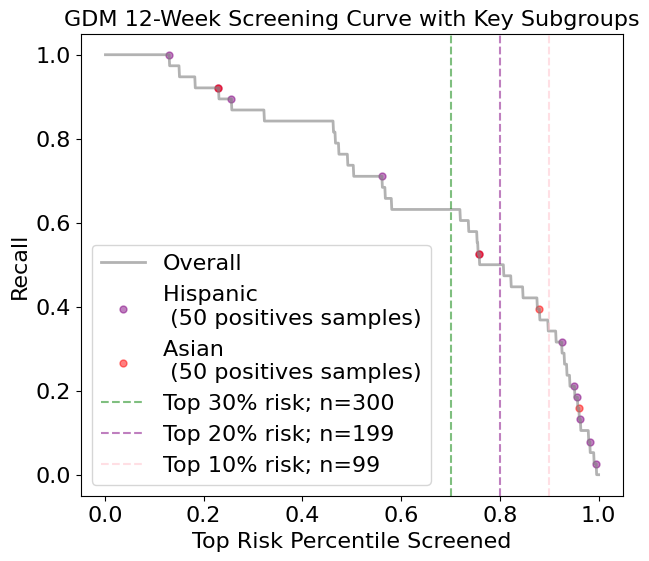

In [56]:
#Create global transform to preserve labels for screening curve after sorting
df_x_test_original = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=feats_to_train
)

df_global = pd.DataFrame({
    "y": y_test,
    "p": test_probs
})

df_global["orig_idx"] = df_global.index

df_global = df_global.sort_values("p", ascending=False).reset_index(drop=True)

df_global["percentile"] = np.arange(len(df_global)) / len(df_global)
df_global["percentile_flipped"] = 1 - df_global["percentile"]

total_positives = df_global["y"].sum()
df_global["cum_positives"] = df_global["y"].cumsum()
df_global["recall"] = df_global["cum_positives"] / total_positives

plt.figure(figsize=(7,6))

plt.plot(
    df_global["percentile_flipped"],
    df_global["recall"],
    label="Overall",
    linewidth=2,
    color = 'grey',
    alpha = 0.6
)

df_global["orig_idx"] = df_global.index 

print(df_global.head())

df_x_test = df_x_test_original.copy().reset_index(drop=True)
df_y_test = y_test.copy().reset_index(drop=True)

print(df_x_test.head())
conditions = generate_conditions(df_x_test)

#colors for point on screening curve
colors = {
    "Hispanic": "purple",
    "Asian": "red",
}

#Cycle for screening curve
for group, condition in conditions.items():

    subgroup_indices = df_x_test[condition].index

    subgroup_preds = test_preds[subgroup_indices]
    subgroup_probs = test_probs[subgroup_indices]
    subgroup_targets = df_y_test.loc[subgroup_indices]
    
    if len(subgroup_targets[subgroup_targets == 1]) == 0:
        continue
   
    subgroup_prob_metrics = prob_metrics(
        subgroup_targets,
        subgroup_preds,  
        subgroup_probs, 
        save=False,
        test=subgroup_targets,
    )

    subgroup_perf[group]['AUROC'].append(subgroup_prob_metrics['AUROC'])
    subgroup_perf[group]['AUPRC'].append(subgroup_prob_metrics['AUPRC'])
    
    subgroup_perf_stats[group]['Test'].append(subgroup_targets.sum())
    subgroup_perf_stats[group]['Total'].append(len(subgroup_targets))

    print("Average Positive Case Risk " + str(group) + ": " + str(round(subgroup_probs[subgroup_targets == 1].mean(), 5)))
    print("Average Negative Case Risk " + str(group) + ": " + str(round(subgroup_probs[subgroup_targets == 0].mean(), 5)))


    subgroup_idx = df_x_test[condition].index

    subgroup_points = df_global[
        (df_global["orig_idx"].isin(subgroup_idx)) & 
        (df_global["y"] == 1)
        ]
    
    n_total = len(df_global)

    df_global["n_screened"] = (1 - df_global["percentile"]) * n_total

    if len(subgroup_points) == 0:
        continue

    sample_points = subgroup_points.sample(
        min(50, len(subgroup_points)),
        random_state=42
    )
    
    if group in ['Asian', 'Hispanic']:
        plt.scatter(
            sample_points["percentile_flipped"],
            sample_points["recall"],
            s=25,
            alpha=0.5,
            label=f"{group} \n (50 positives samples)",
            color=colors.get(group, None)
        )
    print("---")
    
for thresh, color, per in zip([0.7, 0.8, 0.9], ['green', 'purple', 'pink'], ['30%', '20%', '10%']):
    n_screened = int((1 - thresh) * n_total)
    plt.axvline(thresh, linestyle="--", label="Top " + per + " risk; n=" + str(n_screened), alpha=0.5, color = color)

plt.xlabel("Top Risk Percentile Screened", fontsize=16)
plt.ylabel("Recall", fontsize=16)
plt.title("GDM 12-Week Screening Curve with Key Subgroups", fontsize=16)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [57]:
# =============================================================================
# Compute base metrics (threshold-level PPV/sensitivity/NNS).
# Cost-effectiveness analysis lives in the
# `GDM PTB Cost-Effectiveness Analysis` notebook, which loads
# GDM_12w_base_metrics.csv produced below.
# =============================================================================

def compute_base_metrics(y_true, y_pred_proba, percentiles=[99, 95, 90, 80]):
    """Compute threshold metrics that don't depend on intervention choice."""
    results = []
    n_total = len(y_true)
    n_positive = int(y_true.sum())
    prevalence = n_positive / n_total
    
    metadata = {
        'n_total': n_total,
        'n_positive': n_positive,
        'prevalence': prevalence
    }
    
    print(f"Test set size: {n_total:,}")
    print(f"Positive cases: {n_positive:,}")
    print(f"Prevalence: {prevalence:.1%}\n")
    
    for pct in percentiles:
        threshold = np.percentile(y_pred_proba, pct)
        y_pred = (y_pred_proba >= threshold).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        
        pct_screened = 100 - pct
        n_flagged = tp + fp
        nns = 1/ppv if ppv > 0 else float('inf')
        
        results.append({
            'threshold_percentile': pct,
            'threshold_label': f'Top {pct_screened}%',
            'n_flagged': n_flagged,
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv,
            'nns': nns
        })
    
    return pd.DataFrame(results), metadata

df_base, metadata = compute_base_metrics(y_test, test_probs)
df_base.to_csv('/results/GDM_12w_base_metrics.csv', index=False)
print("Saved base metrics to GDM_12w_base_metrics.csv")
print(df_base.to_string(index=False))


Test set size: 1,000
Positive cases: 38
Prevalence: 3.8%

Saved base metrics to GDM_12w_base_metrics.csv
 threshold_percentile threshold_label  n_flagged  tp  fp  tn  fn  sensitivity  specificity   ppv      npv       nns
                   99          Top 1%         10   1   9 953  37     0.026316     0.990644 0.100 0.962626 10.000000
                   95          Top 5%         50   8  42 920  30     0.210526     0.956341 0.160 0.968421  6.250000
                   90         Top 10%        100  13  87 875  25     0.342105     0.909563 0.130 0.972222  7.692308
                   80         Top 20%        200  19 181 781  19     0.500000     0.811850 0.095 0.976250 10.526316
